# Deep Neural Network - Car Preference Learning

**Aleksander Hański 160315 and Michał Żurawski 160252**

We train a plain feed-forward neural network (`4 -> 32 -> 32 -> 16 -> 1`) with
ReLU activations and **no monotone constraints**.  This is the
unconstrained, flexible counterpart to the ANN-UTADIS model - it is
not interpretable by construction, so we rely on post-hoc explanation tools
(PDP, ICE, permutation feature importance and SHAP) to recover whatever
preference structure the network has learned.

We can still say meaningful things about criterion influence, monotonicity and preference thresholds
- even when the model itself does not give them away for free.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import shap

from common_cars import (
    FEATURE_NAMES, CRITERION_DIRECTION, CRITERION_UNIT,
    load_data, report_metrics, select_three_alternatives, get_name,
    find_min_flip_sampling,
    permutation_feature_importance, plot_permutation_importance,
    plot_pdp_ice_grid, manual_pdp,
)

torch.manual_seed(1)
np.random.seed(1)

## 1. Load data

In [2]:
df_raw, df, X, y, X_train, X_test, y_train, y_test, FEATURE_RANGES = load_data()
print(df.shape)

(177, 8)


## 2. Scale features to [0, 1]

We **do not** invert the cost criterion here - we want the network to
learn the direction itself, so that the post-hoc explanations reveal
whether a free-form deep model really picks up the gain/cost structure
without being told.

In [3]:
def normalise(X_raw: pd.DataFrame) -> np.ndarray:
    Xn = X_raw[FEATURE_NAMES].astype(float).copy()
    for f in FEATURE_NAMES:
        lo, hi = FEATURE_RANGES[f]
        Xn[f] = (Xn[f] - lo) / (hi - lo)
    return Xn.values.astype(np.float32)


X_train_n = normalise(X_train)
X_test_n  = normalise(X_test)
X_all_n   = normalise(X)

## 3. Deep NN architecture

In [4]:
class DeepNN(nn.Module):
    def __init__(self, n_in: int = 4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 32), nn.ReLU(),
            nn.Linear(32, 32),  nn.ReLU(),
            nn.Linear(32, 16),  nn.ReLU(),
            nn.Linear(16, 1),
        )

    def logits(self, x):
        return self.net(x).squeeze(-1)

    def forward(self, x):
        return torch.sigmoid(self.logits(x))

## 4. Train

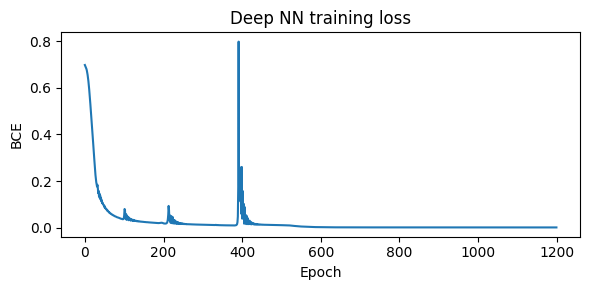

In [5]:
model = DeepNN()
opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)

Xt = torch.tensor(X_train_n, dtype=torch.float32)
yt = torch.tensor(y_train.values, dtype=torch.float32)

loss_hist = []
for epoch in range(1200):
    opt.zero_grad()
    logits = model.logits(Xt)
    loss = nn.functional.binary_cross_entropy_with_logits(logits, yt)
    loss.backward()
    opt.step()
    loss_hist.append(float(loss.item()))

plt.figure(figsize=(6, 3))
plt.plot(loss_hist)
plt.title("Deep NN training loss")
plt.xlabel("Epoch"); plt.ylabel("BCE")
plt.tight_layout(); plt.show()

## 5. Metrics: Accuracy, F1, AUC

In [6]:
def _as_frame(X) -> pd.DataFrame:
    if isinstance(X, pd.DataFrame):
        return X
    arr = np.asarray(X)
    if arr.ndim == 1:
        arr = arr.reshape(1, -1)
    return pd.DataFrame(arr, columns=FEATURE_NAMES)


def predict_proba_df(X_df) -> np.ndarray:
    with torch.no_grad():
        Xn = normalise(_as_frame(X_df))
        return model(torch.tensor(Xn, dtype=torch.float32)).numpy()


def predict_df(X_df) -> np.ndarray:
    return (predict_proba_df(X_df) > 0.5).astype(int)


report_metrics(predict_df, predict_proba_df, X_train, y_train, X_test, y_test)

Train | Accuracy=1.0000  F1=1.0000  AUC=1.0000
Test  | Accuracy=1.0000  F1=1.0000  AUC=1.0000


{'Train': {'Accuracy': 1.0, 'F1': 1.0, 'AUC': 1.0},
 'Test': {'Accuracy': 1.0, 'F1': 1.0, 'AUC': 1.0}}

## 6. Partial Dependence Plots and ICE

PDP reveals the marginal effect of each criterion on the predicted
probability.  If the curve is monotone, the network recovered the correct
gain/cost direction for that criterion **even without being told**.
A flat region = preference indifference in the model.

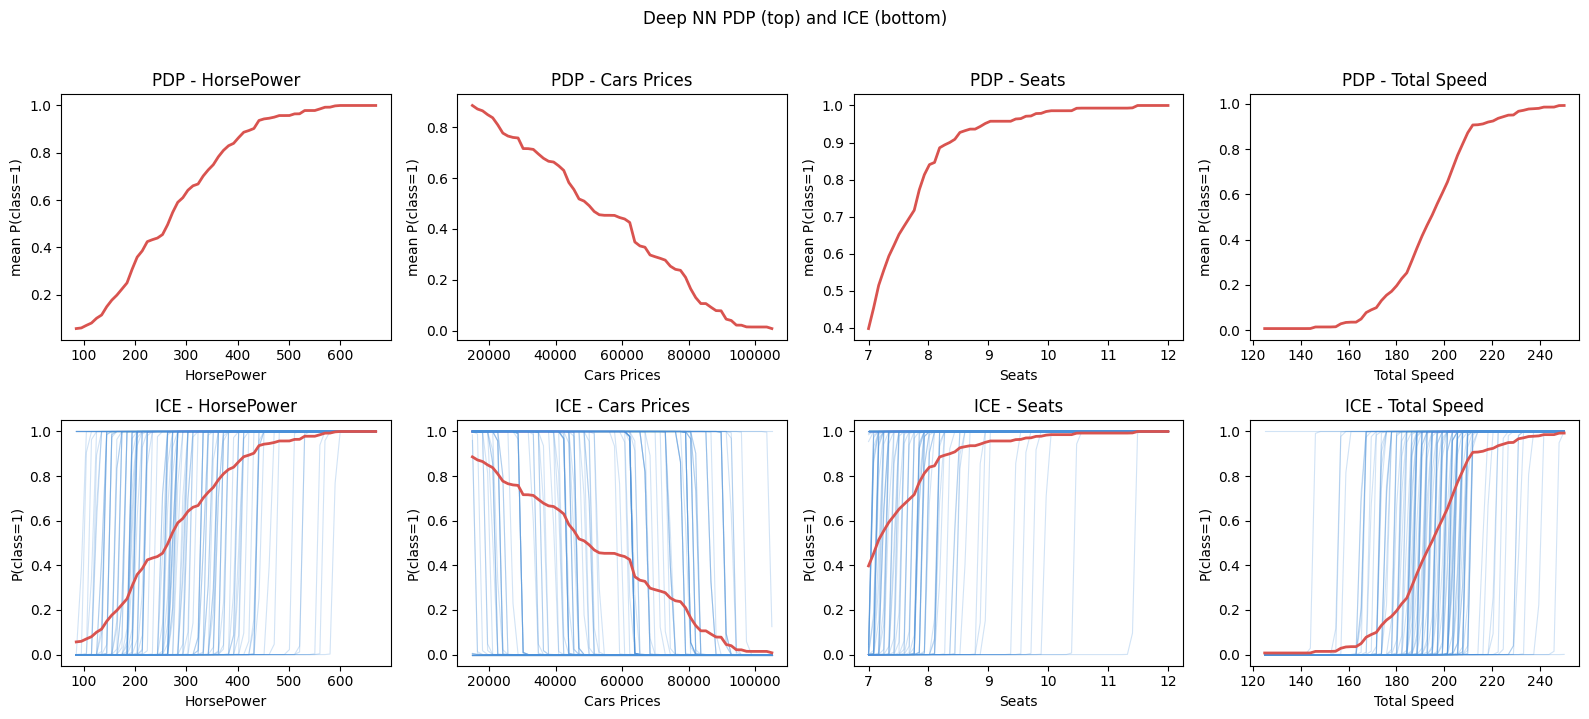

Monotonicity check from PDP slopes:
  HorsePower      slope=+0.00180  expected=+1  ✓
  Cars Prices     slope=-0.00001  expected=-1  ✓
  Seats           slope=+0.08459  expected=+1  ✓
  Total Speed     slope=+0.01059  expected=+1  ✓


In [7]:
plot_pdp_ice_grid(predict_proba_df, X_train, FEATURE_NAMES, FEATURE_RANGES,
                  title_prefix="Deep NN PDP (top) and ICE (bottom)")

# Check whether the learned PDP matches the expected criterion direction
print("Monotonicity check from PDP slopes:")
for f in FEATURE_NAMES:
    xs, pdp = manual_pdp(predict_proba_df, X_train, f, FEATURE_RANGES[f], grid=40)
    slope = float(np.polyfit(xs, pdp, 1)[0])
    expected = CRITERION_DIRECTION[f]
    ok = "✓" if np.sign(slope) == expected else "✗"
    print(f"  {f:14s}  slope={slope:+.5f}  expected={expected:+d}  {ok}")

## 7. Permutation Feature Importance

Permutation importance (AUC drop):
  HorsePower      +0.3532 ± 0.0291
  Total Speed     +0.3191 ± 0.0339
  Cars Prices     +0.2159 ± 0.0216
  Seats           +0.1240 ± 0.0188


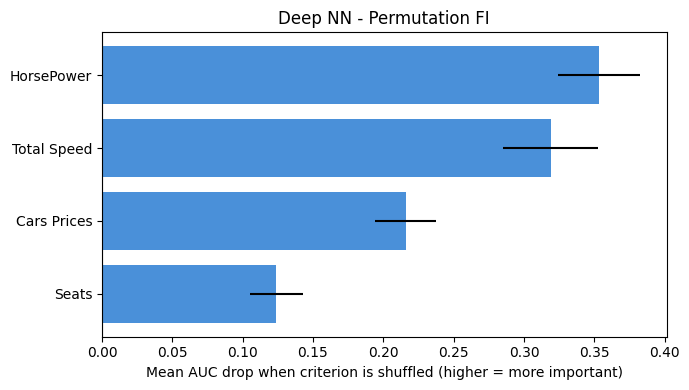

In [8]:
pfi = permutation_feature_importance(predict_proba_df, X_train, y_train,
                                     feature_names=FEATURE_NAMES, n_repeats=30)
print("Permutation importance (AUC drop):")
for f, (m, s) in sorted(pfi.items(), key=lambda kv: -kv[1][0]):
    print(f"  {f:14s}  {m:+.4f} ± {s:.4f}")
plot_permutation_importance(pfi, title="Deep NN - Permutation FI")

## 8. Select 3 alternatives

In [9]:
df_pred = df.copy()
df_pred['pred']      = predict_df(X)
df_pred['pred_prob'] = predict_proba_df(X)

selected = select_three_alternatives(df_pred)
print("Selected alternatives:")
for idx, lbl in selected:
    row = df_pred.loc[idx]
    print(f"  [{lbl}] {get_name(df_raw, idx)}")
    print(f"    HP={row['HorsePower']:.0f} hp, Price=${row['Cars Prices']:.0f}, "
          f"Seats={row['Seats']:.0f}, Speed={row['Total Speed']:.0f} km/h")
    print(f"    Utility={row['utility']:.4f}  Pred prob={row['pred_prob']:.4f}  Class={int(row['pred'])}")

Selected alternatives:
  [Preferred] TOYOTA TOYOTA SEQUOIA
    HP=381 hp, Price=$50000, Seats=7, Speed=200 km/h
    Utility=1.7171  Pred prob=1.0000  Class=1
  [Borderline] Mitsubishi Outlander ES
    HP=181 hp, Price=$29000, Seats=7, Speed=190 km/h
    Utility=1.5285  Pred prob=0.9548  Class=1
  [Not preferred] TOYOTA PROACE VERSO ELECTRIC
    HP=136 hp, Price=$55000, Seats=7, Speed=130 km/h
    Utility=0.6827  Pred prob=0.0000  Class=0


## 9. SHAP explanations (KernelExplainer)

For a black-box deep model we use `shap.KernelExplainer`, which estimates
Shapley values by sampling feature coalitions.  The background set is a
summary of the training distribution.

  0%|          | 0/1 [00:00<?, ?it/s]

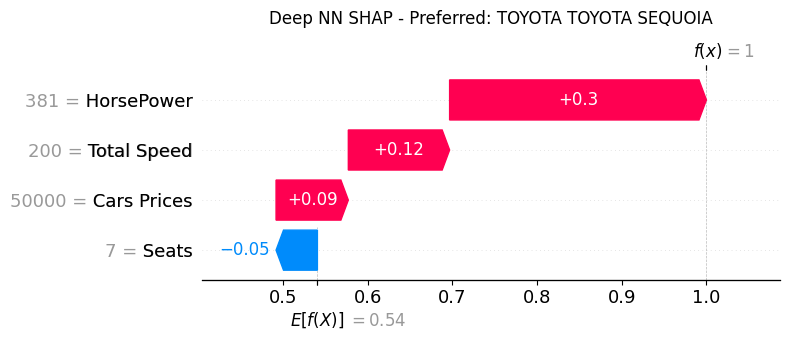

  0%|          | 0/1 [00:00<?, ?it/s]

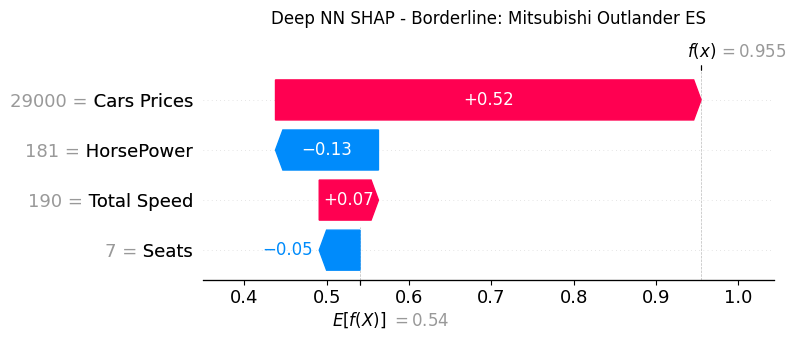

  0%|          | 0/1 [00:00<?, ?it/s]

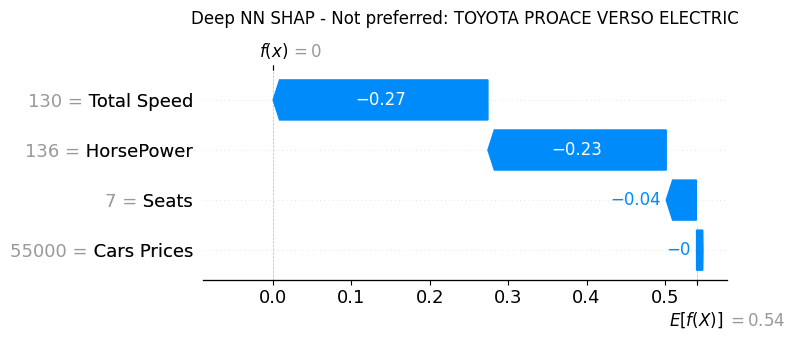

  0%|          | 0/80 [00:00<?, ?it/s]

/tmp/ipykernel_404255/2085488041.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(np.asarray(shap_values_subset), subset, feature_names=FEATURE_NAMES, show=False)


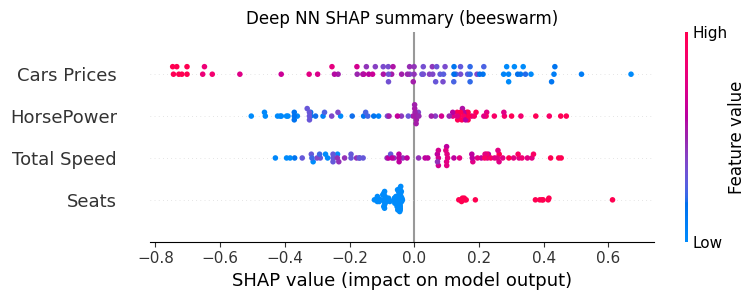

In [10]:
background = shap.sample(X_train, 50, random_state=0)
explainer = shap.KernelExplainer(predict_proba_df, background)

for idx, lbl in selected:
    row = X.loc[[idx]]
    name = get_name(df_raw, idx)
    sv = explainer.shap_values(row, nsamples=200)
    if isinstance(sv, list):
        sv = sv[0]
    sv = np.asarray(sv).reshape(-1)
    explanation = shap.Explanation(
        values        = sv,
        base_values   = float(explainer.expected_value),
        data          = row.values[0],
        feature_names = FEATURE_NAMES,
    )
    shap.plots.waterfall(explanation, show=False)
    plt.title(f"Deep NN SHAP - {lbl}: {name}", pad=12)
    plt.tight_layout()
    plt.show()

# Summary plot on a subset of rows for speed
subset = X.sample(min(len(X), 80), random_state=0)
shap_values_subset = explainer.shap_values(subset, nsamples=200)
if isinstance(shap_values_subset, list):
    shap_values_subset = shap_values_subset[0]
shap.summary_plot(np.asarray(shap_values_subset), subset, feature_names=FEATURE_NAMES, show=False)
plt.title("Deep NN SHAP summary (beeswarm)")
plt.tight_layout()
plt.show()

## 10. Minimum single-criterion change to flip class - analytical linearisation

A deep network has no closed-form decision boundary, but at any point we
can linearise the model and *analytically* estimate the Δ needed to move
the predicted probability to 0.5.  Using the logit (pre-sigmoid) output
`z(x)` - since `sigmoid(z) = 0.5 ⇔ z = 0` - we compute

    Δx_j ≈ −z(x) / ∂z/∂x_j

per criterion and convert back from the normalised [0,1] scale to the raw
unit.  This is a first-order approximation, so we verify it against a true
sampling search below.

In [11]:
def linear_flip_estimate(idx):
    row = df_pred.loc[idx]
    x_raw = row[FEATURE_NAMES].values.astype(float)
    x_n   = normalise(pd.DataFrame([x_raw], columns=FEATURE_NAMES))
    x_t   = torch.tensor(x_n, dtype=torch.float32, requires_grad=True)
    z     = model.logits(x_t)
    grads = torch.autograd.grad(z.sum(), x_t)[0].numpy()[0]   # dz/dx_normalised
    z_val = float(z.item())
    current_pred = int(z_val > 0)
    results = []
    for j, f in enumerate(FEATURE_NAMES):
        g = float(grads[j])
        if abs(g) < 1e-8:
            continue
        delta_n = -z_val / g                           # required change on normalised scale
        lo, hi = FEATURE_RANGES[f]
        delta_raw = delta_n * (hi - lo)
        new_raw = x_raw[j] + delta_raw
        if new_raw < lo or new_raw > hi:
            # The linearisation points outside the feasible range - still report
            # the estimate, but mark it as out-of-range so the sampling step
            # knows to clip.
            feasible = False
        else:
            feasible = True
        results.append({
            'criterion': f,
            'orig_value': float(x_raw[j]),
            'new_value': float(new_raw),
            'delta': float(delta_raw),
            'feasible': feasible,
            'old_pred': current_pred,
        })
    return current_pred, results


print("=" * 60)
analytical_results = {}
for idx, lbl in selected:
    name = get_name(df_raw, idx)
    current, flips = linear_flip_estimate(idx)
    print(f"\n[{lbl}] {name}  (class = {current})")
    if not flips:
        print("  -> gradient is ~0 everywhere; no linear estimate")
    for f in flips:
        flag = "" if f['feasible'] else "  (out of range - clipped at sampling)"
        print(f"  -> '{f['criterion']}' : {f['orig_value']:.1f} -> {f['new_value']:.1f}  "
              f"(Δ ≈ {f['delta']:+.1f}){flag}")
    analytical_results[idx] = flips


[Preferred] TOYOTA TOYOTA SEQUOIA  (class = 1)
  -> 'HorsePower' : 381.0 -> 198.6  (Δ ≈ -182.4)
  -> 'Cars Prices' : 50000.0 -> 77474.4  (Δ ≈ +27474.4)
  -> 'Seats' : 7.0 -> 5.3  (Δ ≈ -1.7)  (out of range - clipped at sampling)
  -> 'Total Speed' : 200.0 -> 158.5  (Δ ≈ -41.5)

[Borderline] Mitsubishi Outlander ES  (class = 1)
  -> 'HorsePower' : 181.0 -> 177.8  (Δ ≈ -3.2)
  -> 'Cars Prices' : 29000.0 -> 29496.3  (Δ ≈ +496.3)
  -> 'Seats' : 7.0 -> 7.0  (Δ ≈ -0.0)  (out of range - clipped at sampling)
  -> 'Total Speed' : 190.0 -> 189.2  (Δ ≈ -0.8)

[Not preferred] TOYOTA PROACE VERSO ELECTRIC  (class = 0)
  -> 'HorsePower' : 136.0 -> 1234.4  (Δ ≈ +1098.4)  (out of range - clipped at sampling)
  -> 'Cars Prices' : 55000.0 -> -57679.7  (Δ ≈ -112679.7)  (out of range - clipped at sampling)
  -> 'Seats' : 7.0 -> 16.0  (Δ ≈ +9.0)  (out of range - clipped at sampling)
  -> 'Total Speed' : 130.0 -> 383.2  (Δ ≈ +253.2)  (out of range - clipped at sampling)


## 11. Sampling verification

For each selected alternative we run the model-agnostic grid search from
`common_cars.find_min_flip_sampling`.  This is the ground truth for the
minimum single-criterion flip.  We then compare the analytical linearised
Δ from Section 10 against the true Δ - agreement is evidence that the
local linearisation is reasonable in this neighbourhood.

In [12]:
print("=" * 60)
for idx, lbl in selected:
    name = get_name(df_raw, idx)
    row  = df_pred.loc[idx]
    print(f"\n[{lbl}] {name}  (original class = {int(row['pred'])})")

    grid_flips = find_min_flip_sampling(predict_df, row, FEATURE_NAMES,
                                        FEATURE_RANGES, grid=500)
    if not grid_flips:
        print("  No flip possible by single-criterion change.")
        continue

    grid_best = min(grid_flips, key=lambda r: abs(r['delta']))
    print(f"  Sampling best: '{grid_best['criterion']}' Δ={grid_best['delta']:+.1f}  "
          f"-> class {grid_best['new_pred']}")

    # Compare to the linearisation result for the same criterion
    ana = analytical_results.get(idx, [])
    same_feat = next((a for a in ana if a['criterion'] == grid_best['criterion']), None)
    if same_feat is not None:
        diff = same_feat['delta'] - grid_best['delta']
        print(f"  Linearised   : Δ≈{same_feat['delta']:+.1f}   "
              f"(discrepancy with sampling: {diff:+.2f})")


[Preferred] TOYOTA TOYOTA SEQUOIA  (original class = 1)
  Sampling best: 'Total Speed' Δ=-26.9  -> class 0
  Linearised   : Δ≈-41.5   (discrepancy with sampling: -14.63)

[Borderline] Mitsubishi Outlander ES  (original class = 1)
  Sampling best: 'Total Speed' Δ=-0.9  -> class 0
  Linearised   : Δ≈-0.8   (discrepancy with sampling: +0.09)

[Not preferred] TOYOTA PROACE VERSO ELECTRIC  (original class = 0)
  Sampling best: 'Seats' Δ=+4.4  -> class 1
  Linearised   : Δ≈+9.0   (discrepancy with sampling: +4.57)


## 12. Model interpretation summary

* **Criterion influence**: the permutation importance and SHAP beeswarm
  both identify which criteria the network relies on most.  Disagreement
  between the two is a signal that the network uses a criterion mainly
  through interactions (PFI reflects total contribution; mean |SHAP|
  reflects direct marginal contribution at observed points).

* **Criterion nature (gain / cost / non-monotone)**: the monotonicity
  check in Section 6 reads the slope of each PDP curve.  A matching sign
  with `CRITERION_DIRECTION` means the unconstrained network recovered
  the "correct" direction; a mismatch would reveal that the network
  learned a non-monotone response in some region - worth flagging,
  because ANN-UTADIS cannot represent that.

* **Preference thresholds**: sharp transitions in the PDP curve correspond
  to model-internal thresholds.  Flat PDP regions = criterion values the
  model treats as effectively equivalent ("indifference zones").

* **Criterion dependencies**: the spread of ICE curves around the PDP
  mean quantifies interaction effects.  Under ANN-UTADIS that spread is
  zero by construction; here any spread is direct evidence of learned
  criterion interactions.

* **Contrast with ANN-UTADIS**: both models should agree on the ordering
  of criterion importance if the user's preferences are well-described by
  an additive utility.  Differences highlight interaction effects that
  the additive model cannot represent.